# Treemap

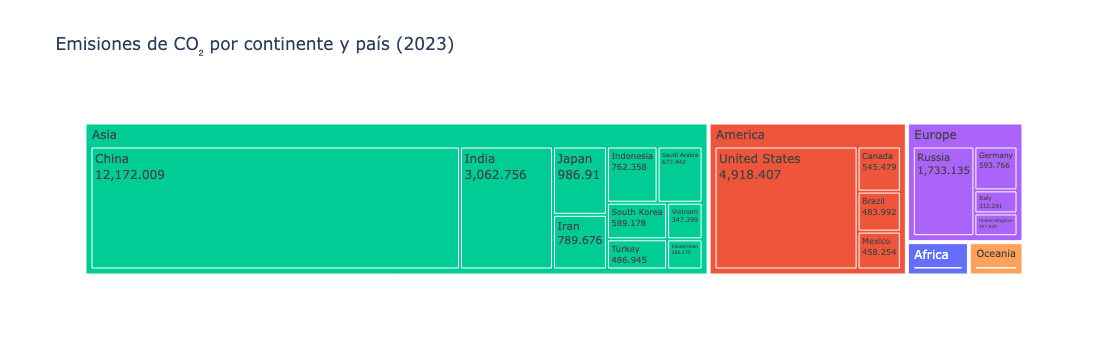

In [16]:
import pandas as pd
import plotly.express as px
import country_converter as coco

# cargar datos
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# filtrar año 2023
df = df[df["year"] == 2023].copy()

# quedarnos con países reales:
# - códigos ISO de 3 letras
# - emisiones no nulas
df = df[df["iso_code"].str.len() == 3]
df = df.dropna(subset=["co2"])

# convertir ISO3 a continente
df["continent"] = coco.convert(names=df["iso_code"], to="continent")

# quitar registros sin continente válido
df = df[df["continent"] != "not found"]

# quedarnos con los 20 países con más emisiones
df = df.sort_values("co2", ascending=False).head(20)

# renombrar columnas para que quede más claro
df = df.rename(columns={"country": "Country", "co2": "CO2", "continent": "Continent"})

# crear treemap
fig = px.treemap(
    df,
    path=["Continent", "Country"],
    values="CO2",
    color="Continent",
    title="Emisiones de CO₂ por continente y país (2023)"
)

# mejorar aspecto
fig.update_traces(
    textinfo="label+value",
    hovertemplate="<b>%{label}</b><br>CO₂: %{value:.2f} Mt<extra></extra>"
)

fig.show()

# guardar en html y png
fig.write_html("treemap_co2.html")
fig.write_image("treemap_co2.png")

# Matrix Plot

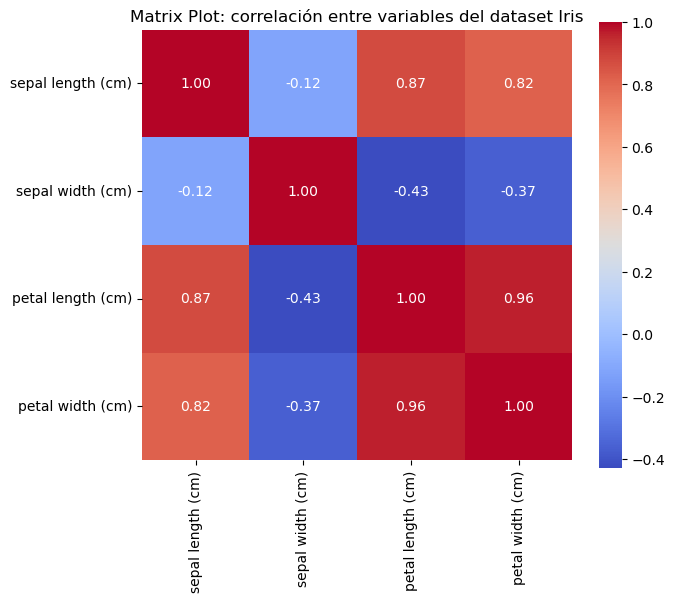

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# cargar dataset iris
iris = load_iris(as_frame=True)
df = iris.frame

# quedarnos solo con variables numéricas
num = df.drop(columns=["target"])

# matriz de correlación
corr = num.corr()

# gráfico
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Matrix Plot: correlación entre variables del dataset Iris")
plt.tight_layout()
plt.savefig("matrix_plot_iris.png", dpi=300, bbox_inches="tight")
plt.show()

# Ridgeline Charts

/opt/anaconda3/lib/python3.13/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


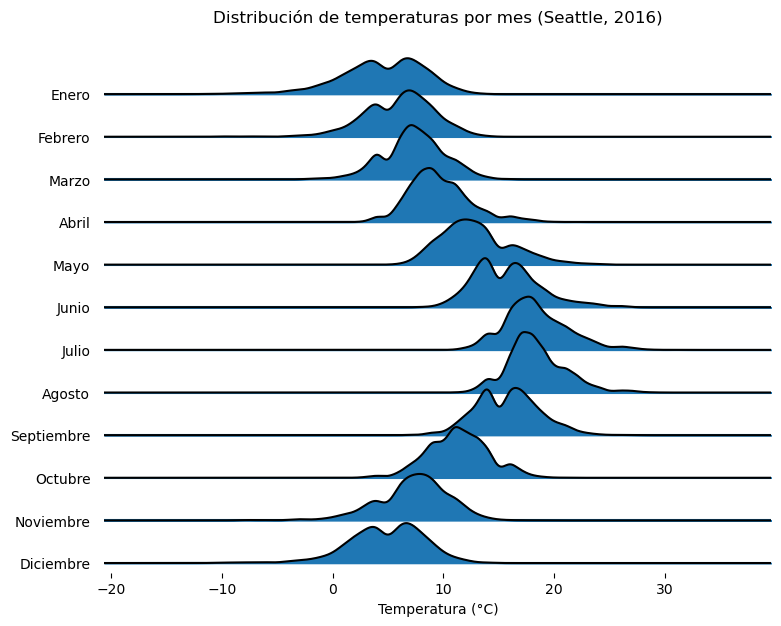

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import joypy

# cargar datos
url = "https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv"
df = pd.read_csv(url)

# convertir fecha
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

# diccionario de meses
meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

df["Month_name"] = df["Month"].map(meses)

orden_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

df["Month_name"] = pd.Categorical(
    df["Month_name"],
    categories=orden_meses,
    ordered=True
)

# usar temperatura media
df = df.rename(columns={"Mean_TemperatureC": "temp"})

# eliminar nulos
df = df.dropna(subset=["temp"])

# ridgeline
fig, ax = joypy.joyplot(
    data=df,
    by="Month_name",
    column="temp",
    figsize=(8,6),
    legend=False,
    overlap=0.5
)

plt.title("Distribución de temperaturas por mes (Seattle, 2016)")
plt.xlabel("Temperatura (°C)")
plt.savefig("ridgeline_temperature.png", dpi=300, bbox_inches="tight")
plt.show()